In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
df = pd.read_csv("dataset.csv")


In [6]:
print(f"\n Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\n Столбцы:\n{df.columns.tolist()}")


 Размер датасета: 958524 строк, 45 столбцов

 Столбцы:
['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch', 'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']


In [7]:
print("\n Информация о данных:")
df_info = pd.DataFrame({
    'Тип данных': df.dtypes,
    'Пропуски (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Уникальные значения': df.nunique()
})
print(df_info)


 Информация о данных:
               Тип данных  Пропуски (%)  Уникальные значения
id                 object          0.00               958524
spkid               int64          0.00               958524
full_name          object          0.00               958524
pdes               object          0.00               958524
name               object         97.70                22064
prefix             object        100.00                    1
neo                object          0.00                    2
pha                object          2.08                    2
H                 float64          0.65                 9489
diameter          float64         85.79                16591
albedo            float64         85.91                 1057
diameter_sigma    float64         85.80                 3054
orbit_id           object          0.00                 4690
epoch             float64          0.00                 5246
epoch_mjd           int64          0.00                 5246
e

In [8]:
print("\n Статистика числовых признаков:")
display(df.describe())


 Статистика числовых признаков:


,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


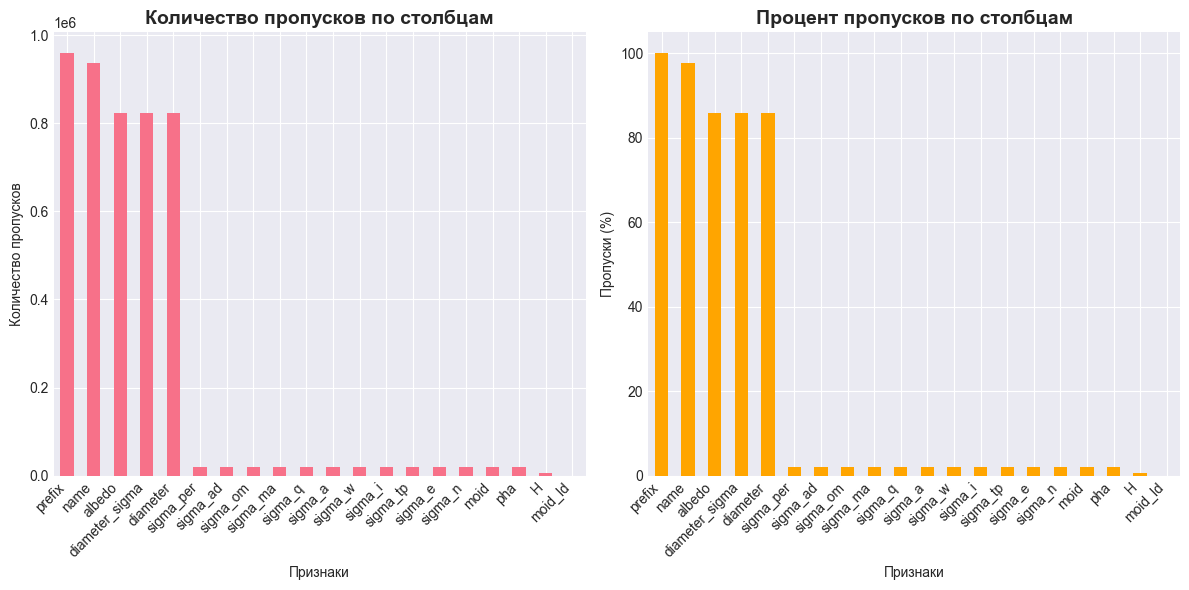

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
df.isnull().sum().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Количество пропусков по столбцам', fontsize=14, fontweight='bold')
plt.xlabel('Признаки')
plt.ylabel('Количество пропусков')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(20)
missing_percent.plot(kind='bar', color='orange')
plt.title('Процент пропусков по столбцам', fontsize=14, fontweight='bold')
plt.xlabel('Признаки')
plt.ylabel('Пропуски (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# Анализ целевой переменной
target_col = 'pha'  # Potentially Hazardous Asteroid
print(f"\n Целевая переменная: {target_col}")
print(f"Распределение классов:\n{df[target_col].value_counts()}")


 Целевая переменная: pha
Распределение классов:
pha
N    936537
Y      2066
Name: count, dtype: int64


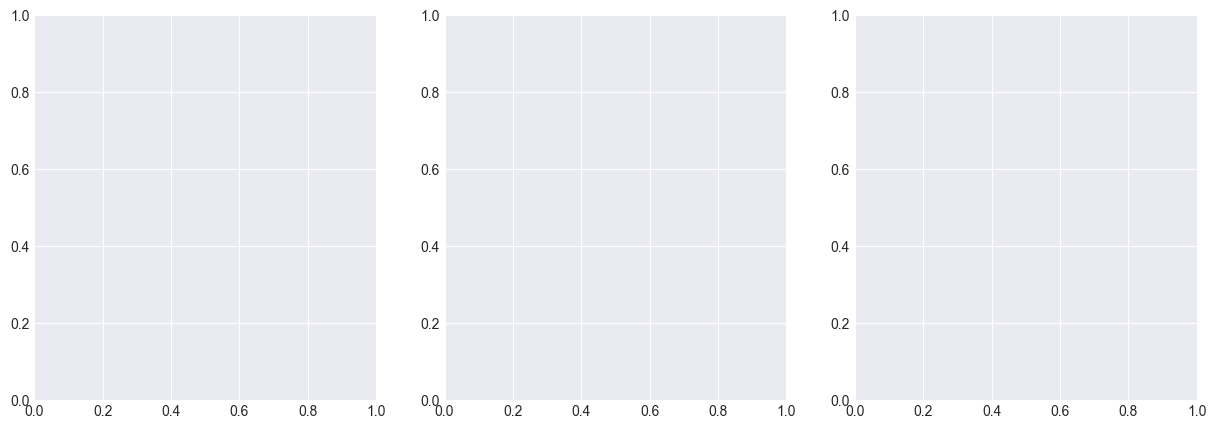

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

In [12]:
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Распределение классов', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Опасный астероид (pha)')
axes[0].set_ylabel('Количество')
axes[0].set_xticklabels(['Неопасный (N)', 'Опасный (Y)'], rotation=0)

[Text(0, 0, 'Неопасный (N)'), Text(1, 0, 'Опасный (Y)')]

In [13]:
df[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1], explode=[0, 0.1])
axes[1].set_title('Соотношение классов', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

Text(414.73856209150335, 0.5, '')

In [14]:
class_counts = df[target_col].value_counts()
imbalance_ratio = class_counts.min() / class_counts.max()
axes[2].bar(['Дисбаланс'], [imbalance_ratio], color='purple')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Соотношение (меньший/больший класс)')
axes[2].set_title(f'Дисбаланс классов: {imbalance_ratio:.3f}', fontsize=14, fontweight='bold')
axes[2].axhline(y=0.5, color='r', linestyle='--', label='Порог 0.5')
axes[2].legend()

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>


 Корреляционный анализ:


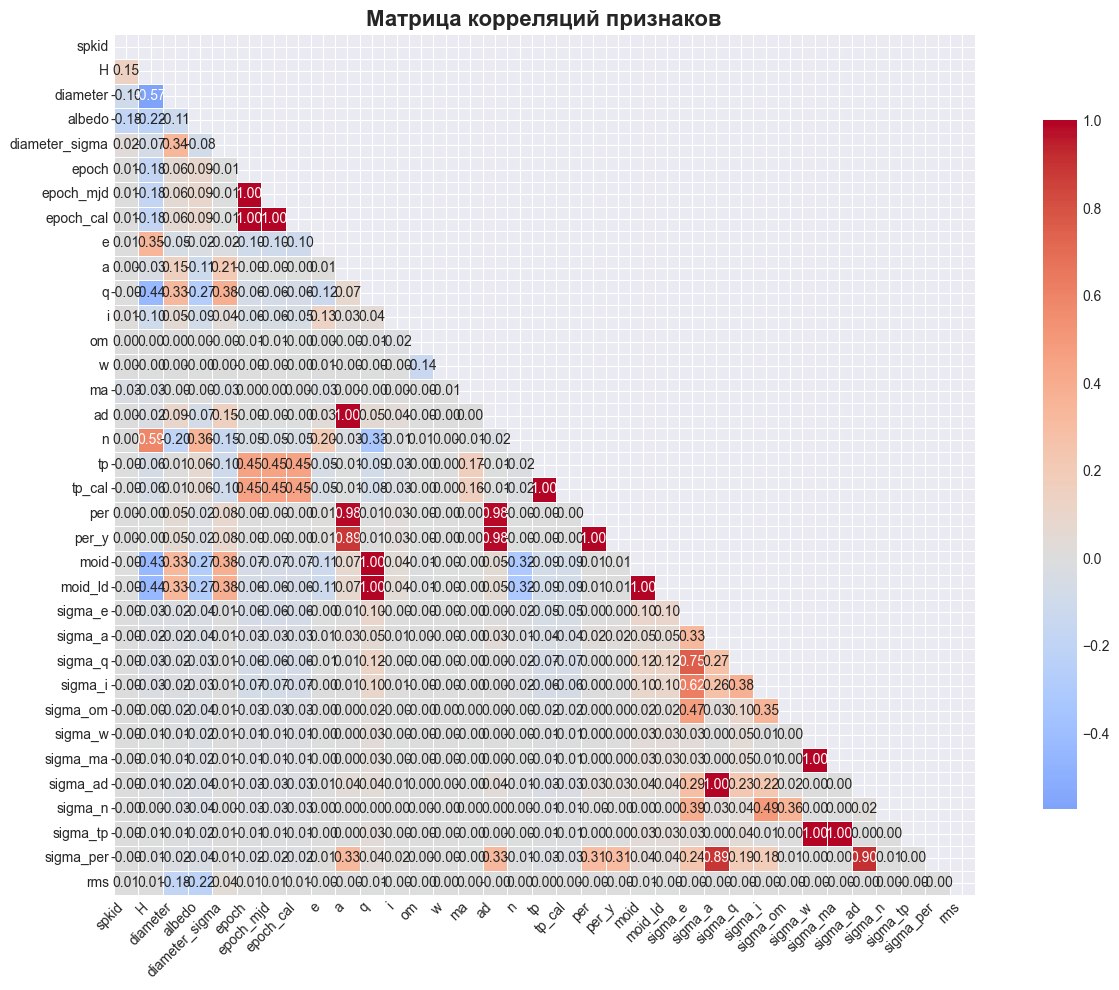

In [15]:
print("\n Корреляционный анализ:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций признаков', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

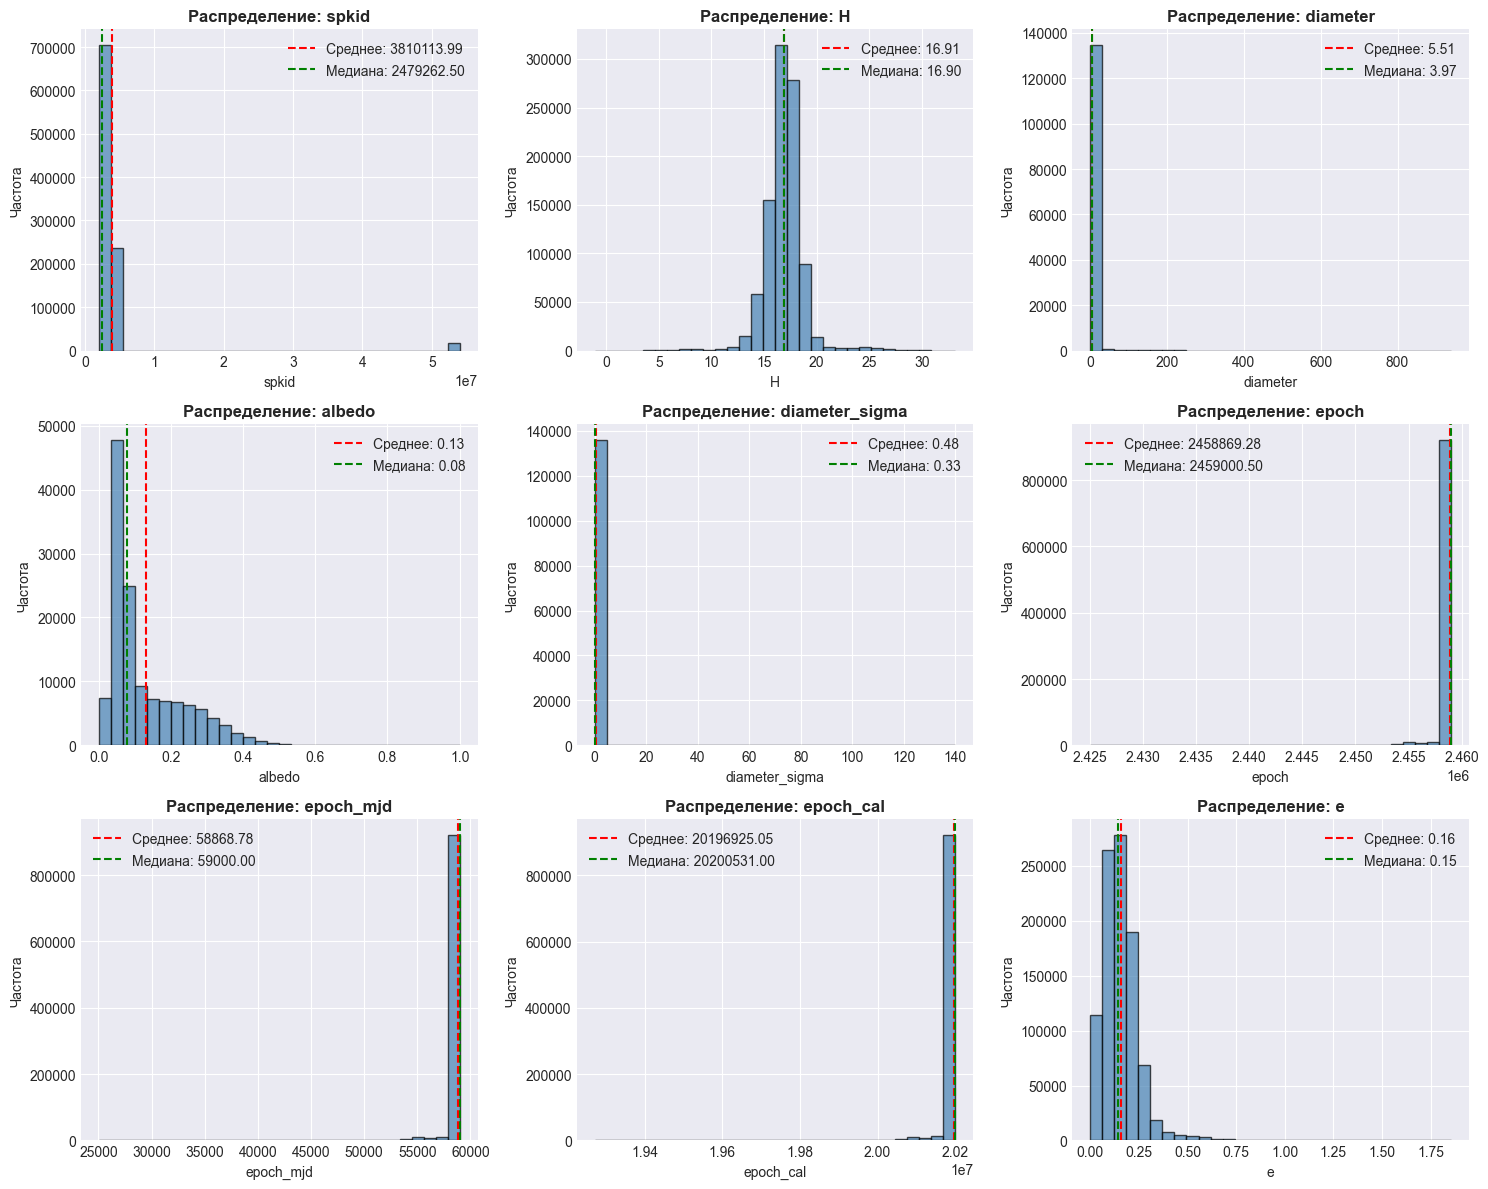

In [16]:
numeric_features = numeric_cols[:9]  # Первые 9 числовых признаков
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Распределение: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Среднее: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', label=f'Медиана: {df[col].median():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [17]:
df_clean = df.copy()

In [18]:
df_clean['target'] = df_clean[target_col].map({'N': 0, 'Y': 1})
print(f"\n Кодирование целевой переменной: N→0, Y→1")


 Кодирование целевой переменной: N→0, Y→1


In [20]:
potential_features = ['diameter', 'H', 'albedo', 'rot_per', 'GM', 'BV', 'UB', 
                      'moid', 'i', 'e', 'a', 'ma', 'q', 'ad', 'n', 'tp', 
                      'per_y', 'data_arc', 'condition_code']

# Оставляем только существующие в датасете
available_features = [col for col in potential_features if col in df_clean.columns]
print(f"\n Доступные числовые признаки: {available_features}")


 Доступные числовые признаки: ['diameter', 'H', 'albedo', 'moid', 'i', 'e', 'a', 'ma', 'q', 'ad', 'n', 'tp', 'per_y']


In [22]:
available_features = [col for col in potential_features if col in df_clean.columns]
print(f"\n Доступные числовые признаки: {available_features}")


 Доступные числовые признаки: ['diameter', 'H', 'albedo', 'moid', 'i', 'e', 'a', 'ma', 'q', 'ad', 'n', 'tp', 'per_y']


In [24]:
# Создаем матрицу признаков X
X_raw = df_clean[available_features].copy()
y = df_clean['target'].copy()

print(f"\n Размер до обработки: X={X_raw.shape}, y={y.shape}")
print(f"Пропуски в X: {X_raw.isnull().sum().sum()}")


 Размер до обработки: X=(958524, 13), y=(958524,)
Пропуски в X: 1671926



 Обработка пропусков:


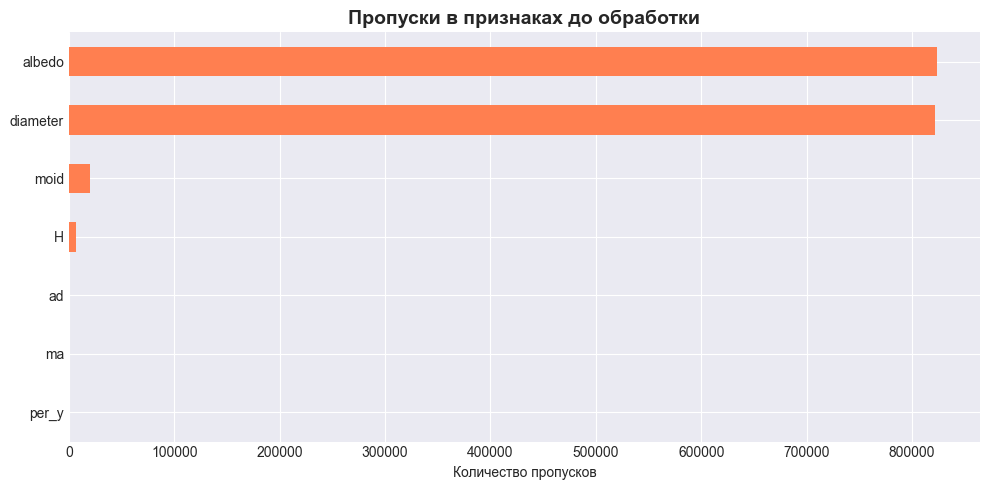

In [26]:
print("\n Обработка пропусков:")

# Визуализация пропусков в выбранных признаках
missing_before = X_raw.isnull().sum()
missing_before = missing_before[missing_before > 0]

if len(missing_before) > 0:
    plt.figure(figsize=(10, 5))
    missing_before.sort_values().plot(kind='barh', color='coral')
    plt.title('Пропуски в признаках до обработки', fontsize=14, fontweight='bold')
    plt.xlabel('Количество пропусков')
    plt.tight_layout()
    plt.show()


In [27]:
for col in X_raw.columns:
    if X_raw[col].isnull().any():
        median_val = X_raw[col].median()
        X_raw[col].fillna(median_val, inplace=True)
        print(f"  - {col}: заполнено {X_raw[col].isnull().sum()} пропусков медианой ({median_val:.3f})")

print(f"\n После обработки пропусков: {X_raw.isnull().sum().sum()} пропусков")


  - diameter: заполнено 0 пропусков медианой (3.972)
  - H: заполнено 0 пропусков медианой (16.900)
  - albedo: заполнено 0 пропусков медианой (0.079)
  - moid: заполнено 0 пропусков медианой (1.241)
  - ma: заполнено 0 пропусков медианой (175.641)
  - ad: заполнено 0 пропусков медианой (3.047)
  - per_y: заполнено 0 пропусков медианой (4.307)

 После обработки пропусков: 0 пропусков



 Анализ выбросов:


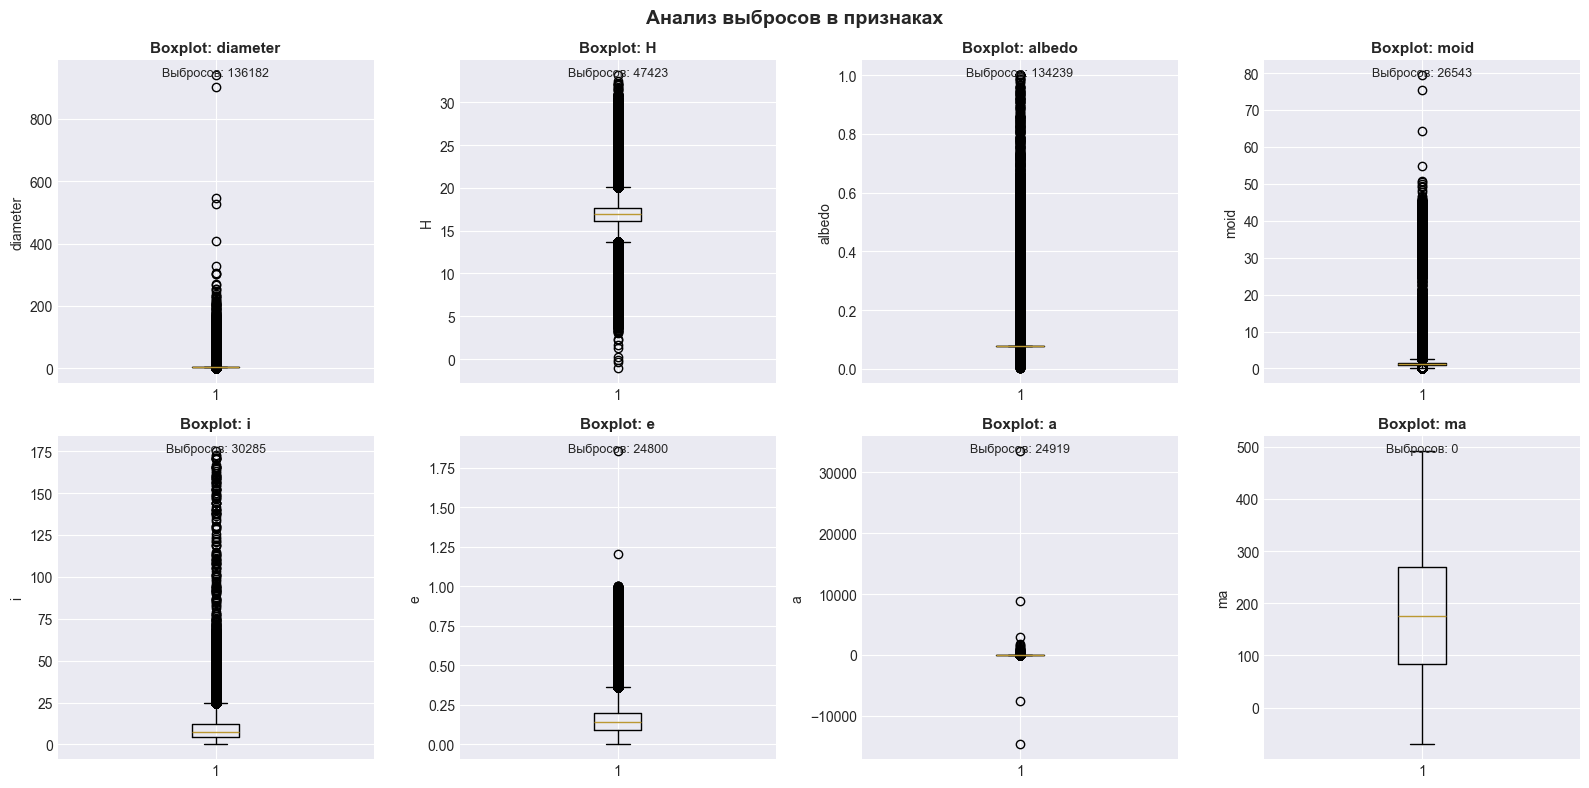

In [28]:
print("\n Анализ выбросов:")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(X_raw.columns[:8]):  # Первые 8 признаков
    # Box plot
    axes[idx].boxplot(X_raw[col], vert=True)
    axes[idx].set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col)
    
    # Расчет IQR для выбросов
    Q1 = X_raw[col].quantile(0.25)
    Q3 = X_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = X_raw[(X_raw[col] < Q1 - 1.5*IQR) | (X_raw[col] > Q3 + 1.5*IQR)]
    axes[idx].text(0.5, 0.95, f'Выбросов: {len(outliers)}', 
                   transform=axes[idx].transAxes, ha='center', fontsize=9)

plt.suptitle('Анализ выбросов в признаках', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 Стандартизация признаков:


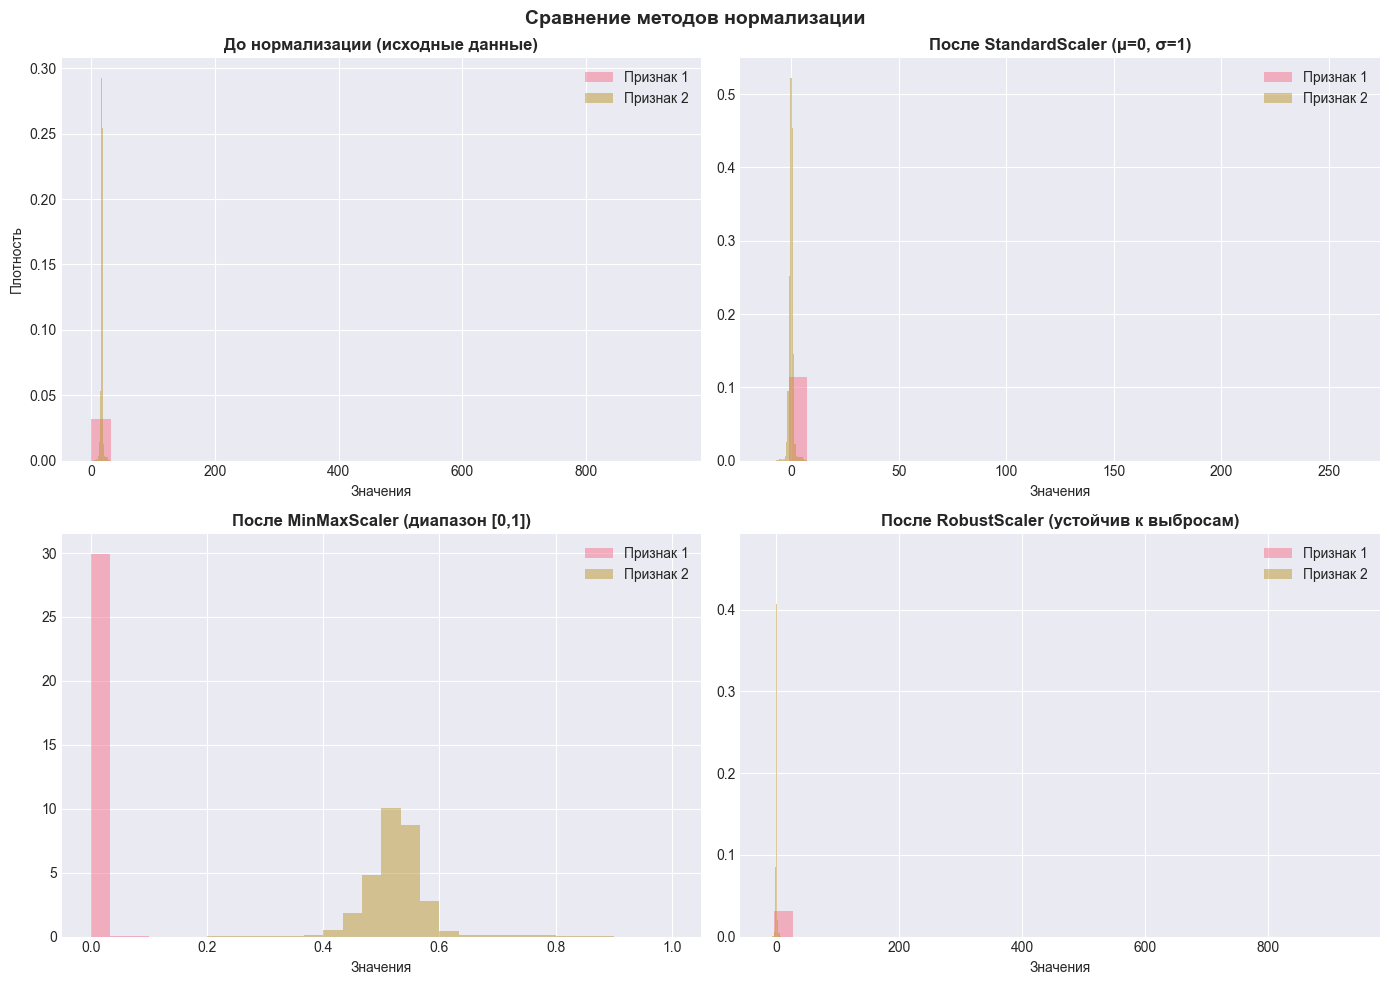

 Выбран StandardScaler для дальнейшей работы


In [29]:
# 5. Стандартизация (нормализация)
print("\n Стандартизация признаков:")

# Сравнение различных методов нормализации
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

X_standard = scaler_standard.fit_transform(X_raw)
X_minmax = scaler_minmax.fit_transform(X_raw)
X_robust = scaler_robust.fit_transform(X_raw)

# Визуализация эффекта нормализации
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# До нормализации
axes[0, 0].hist(X_raw.iloc[:, 0].dropna(), bins=30, alpha=0.5, label='Признак 1', density=True)
axes[0, 0].hist(X_raw.iloc[:, 1].dropna(), bins=30, alpha=0.5, label='Признак 2', density=True)
axes[0, 0].set_title('До нормализации (исходные данные)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Значения')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].legend()

# После StandardScaler
axes[0, 1].hist(X_standard[:, 0], bins=30, alpha=0.5, label='Признак 1', density=True)
axes[0, 1].hist(X_standard[:, 1], bins=30, alpha=0.5, label='Признак 2', density=True)
axes[0, 1].set_title('После StandardScaler (μ=0, σ=1)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Значения')
axes[0, 1].legend()

# После MinMaxScaler
axes[1, 0].hist(X_minmax[:, 0], bins=30, alpha=0.5, label='Признак 1', density=True)
axes[1, 0].hist(X_minmax[:, 1], bins=30, alpha=0.5, label='Признак 2', density=True)
axes[1, 0].set_title('После MinMaxScaler (диапазон [0,1])', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Значения')
axes[1, 0].legend()

# После RobustScaler
axes[1, 1].hist(X_robust[:, 0], bins=30, alpha=0.5, label='Признак 1', density=True)
axes[1, 1].hist(X_robust[:, 1], bins=30, alpha=0.5, label='Признак 2', density=True)
axes[1, 1].set_title('После RobustScaler (устойчив к выбросам)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Значения')
axes[1, 1].legend()

plt.suptitle('Сравнение методов нормализации', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Выбираем StandardScaler для дальнейшей работы
X = X_standard
scaler = scaler_standard
print(" Выбран StandardScaler для дальнейшей работы")

In [30]:

# 1. Univariate feature selection (ANOVA F-value)
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X, y)
f_scores = pd.DataFrame({
    'Feature': available_features,
    'F-score': selector_f.scores_,
    'p-value': selector_f.pvalues_
}).sort_values('F-score', ascending=False)

print("\n Univariate feature selection (ANOVA F-value):")
print(f_scores)

# 2. Mutual Information
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X, y)
mi_scores = pd.DataFrame({
    'Feature': available_features,
    'Mutual Info': mi_selector.scores_
}).sort_values('Mutual Info', ascending=False)

print("\n Mutual Information scores:")
print(mi_scores)

# Визуализация важности признаков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F-score visualization
axes[0].barh(f_scores['Feature'][:10], f_scores['F-score'][:10], color='steelblue')
axes[0].set_xlabel('F-score')
axes[0].set_title('Топ-10 признаков по ANOVA F-value', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Mutual Info visualization
axes[1].barh(mi_scores['Feature'][:10], mi_scores['Mutual Info'][:10], color='coral')
axes[1].set_xlabel('Mutual Information')
axes[1].set_title('Топ-10 признаков по Mutual Information', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 3. Выбор топ признаков (например, топ-5)
top_features = mi_scores['Feature'][:5].tolist()
top_indices = [available_features.index(f) for f in top_features]
X_selected = X[:, top_indices]

print(f"\n Выбрано топ-5 признаков: {top_features}")
print(f"Размер X после отбора: {X_selected.shape}")

# 4. PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel(f'Первая главная компонента ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
plt.ylabel(f'Вторая главная компонента ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
plt.title('Визуализация данных после отбора признаков (PCA)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Класс (0=Неопасный, 1=Опасный)')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Анализ компонент PCA
print("\n Анализ главных компонент:")
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_selected)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная объясненная дисперсия')
plt.title('Объясненная дисперсия в зависимости от числа компонент PCA', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.legend()
plt.show()

ValueError: Input y contains NaN.

In [31]:
# === ИСПРАВЛЕНИЕ: удаляем строки с NaN в целевой переменной ===
print("\n" + "="*80)
print("ПОДГОТОВКА ДАННЫХ (с удалением NaN в target)")
print("="*80)

# Удаляем строки где target = NaN
nan_mask = y.isna()
print(f"Строк с NaN в целевой переменной: {nan_mask.sum()}")

X_raw_clean = X_raw[~nan_mask]
y_clean = y[~nan_mask]

print(f"Размер после удаления NaN: X={X_raw_clean.shape}, y={y_clean.shape}")

# Повторная нормализация на чистых данных
scaler = StandardScaler()
X_scaled_clean = scaler.fit_transform(X_raw_clean)

print(f"\n✅ Данные подготовлены. Пропусков в X: {np.isnan(X_scaled_clean).sum()}")
print(f"Пропусков в y: {np.isnan(y_clean).sum()}")


ПОДГОТОВКА ДАННЫХ (с удалением NaN в target)
Строк с NaN в целевой переменной: 19921
Размер после удаления NaN: X=(938603, 13), y=(938603,)

✅ Данные подготовлены. Пропусков в X: 0
Пропусков в y: 0



ОТБОР ПРИЗНАКОВ

📊 Univariate feature selection (ANOVA F-value):
     Feature       F-score        p-value
5          e  35340.284680   0.000000e+00
10         n  28234.062300   0.000000e+00
1          H   6542.548805   0.000000e+00
8          q   1192.553787  3.700174e-261
4          i   1067.382619  5.496933e-234
3       moid    862.692510  1.543295e-189
0   diameter     47.612545   5.196774e-12
11        tp     13.330014   2.612058e-04
2     albedo      9.678313   1.864614e-03
6          a      1.653101   1.985378e-01
7         ma      1.653096   1.985383e-01
9         ad      0.180898   6.706025e-01
12     per_y      0.006882   9.338866e-01

📊 Mutual Information scores:
     Feature  Mutual Info
2     albedo     0.027910
3       moid     0.010136
8          q     0.009228
1          H     0.008271
0   diameter     0.007674
5          e     0.006600
6          a     0.004673
10         n     0.004672
12     per_y     0.004671
9         ad     0.002735
11        tp     0.000603
4   

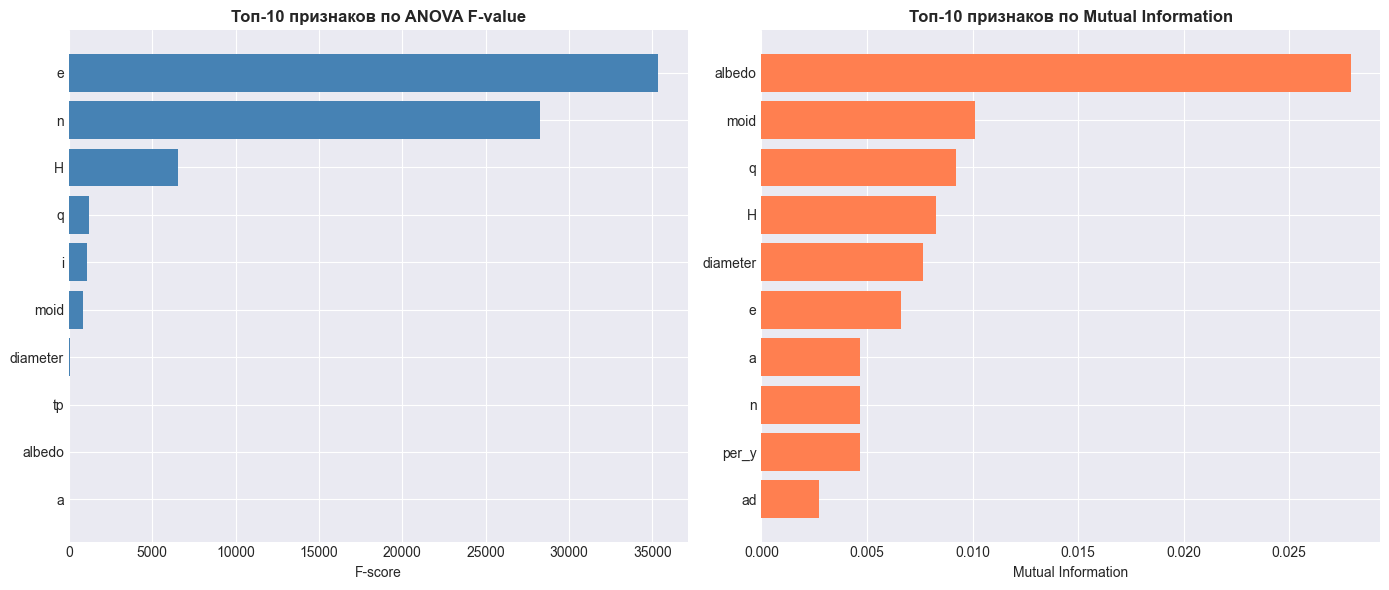


✅ Выбрано топ-5 признаков по Mutual Information: ['albedo', 'moid', 'q', 'H', 'diameter']
Размер X после отбора: (938603, 5)

📊 Альтернативный подход - выбор признаков через SelectKBest:
Выбранные признаки через SelectKBest: ['diameter', 'H', 'albedo', 'moid', 'q']


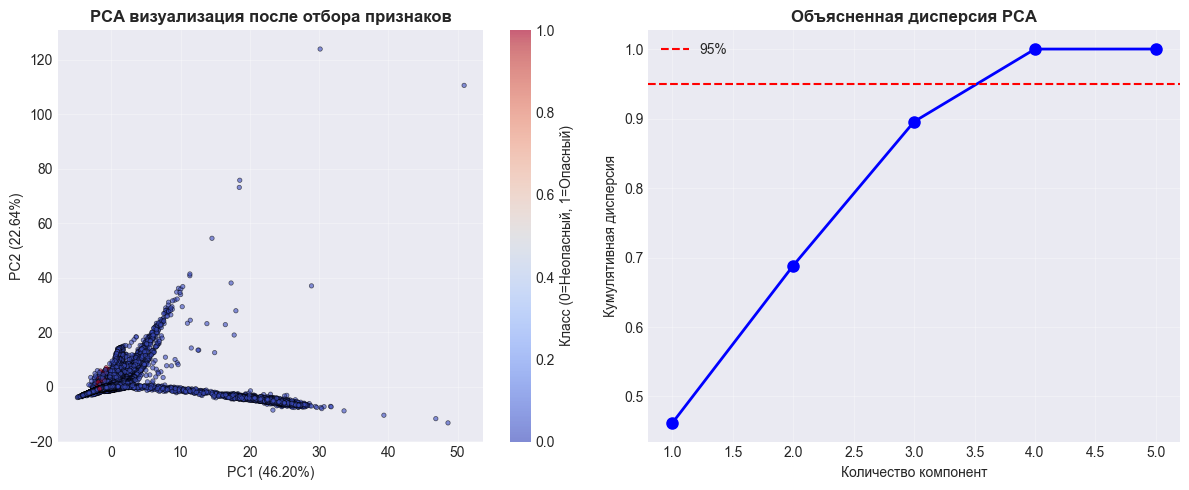


📊 PCA анализ:
Первая компонента объясняет: 46.20% дисперсии
Первые 2 компоненты объясняют: 68.85%
Первые 3 компоненты объясняют: 89.55%


In [34]:
# === ОТБОР ПРИЗНАКОВ (без RFE для k-NN) ===
print("\n" + "="*80)
print("ОТБОР ПРИЗНАКОВ")
print("="*80)

# 1. Univariate feature selection (ANOVA F-value)
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_scaled_clean, y_clean)

f_scores = pd.DataFrame({
    'Feature': available_features,
    'F-score': selector_f.scores_,
    'p-value': selector_f.pvalues_
}).sort_values('F-score', ascending=False)

print("\n📊 Univariate feature selection (ANOVA F-value):")
print(f_scores)

# 2. Mutual Information (лучше для k-NN, так как не предполагает линейной зависимости)
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_scaled_clean, y_clean)

mi_scores = pd.DataFrame({
    'Feature': available_features,
    'Mutual Info': mi_selector.scores_
}).sort_values('Mutual Info', ascending=False)

print("\n📊 Mutual Information scores:")
print(mi_scores)

# Визуализация важности признаков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F-score visualization
axes[0].barh(f_scores['Feature'][:10], f_scores['F-score'][:10], color='steelblue')
axes[0].set_xlabel('F-score')
axes[0].set_title('Топ-10 признаков по ANOVA F-value', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Mutual Info visualization
axes[1].barh(mi_scores['Feature'][:10], mi_scores['Mutual Info'][:10], color='coral')
axes[1].set_xlabel('Mutual Information')
axes[1].set_title('Топ-10 признаков по Mutual Information', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 3. Выбор топ-5 признаков по Mutual Information (рекомендуется для k-NN)
top_features = mi_scores['Feature'][:5].tolist()
top_indices = [available_features.index(f) for f in top_features]
X_selected = X_scaled_clean[:, top_indices]

print(f"\n✅ Выбрано топ-5 признаков по Mutual Information: {top_features}")
print(f"Размер X после отбора: {X_selected.shape}")

# 4. Альтернативный подход: SelectKBest с mutual_info
print("\n📊 Альтернативный подход - выбор признаков через SelectKBest:")
selector_kbest = SelectKBest(score_func=mutual_info_classif, k=5)
X_selected_kbest = selector_kbest.fit_transform(X_scaled_clean, y_clean)
selected_mask = selector_kbest.get_support()
selected_features_kbest = [available_features[i] for i in range(len(available_features)) if selected_mask[i]]
print(f"Выбранные признаки через SelectKBest: {selected_features_kbest}")

# 5. PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_clean, cmap='coolwarm', 
                      alpha=0.6, edgecolors='black', linewidth=0.5, s=10)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('PCA визуализация после отбора признаков', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Класс (0=Неопасный, 1=Опасный)')
plt.grid(True, alpha=0.3)

# 6. Анализ компонент PCA
plt.subplot(1, 2, 2)
pca_full = PCA()
pca_full.fit(X_selected)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumsum)+1), cumsum, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная дисперсия')
plt.title('Объясненная дисперсия PCA', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 PCA анализ:")
print(f"Первая компонента объясняет: {pca_full.explained_variance_ratio_[0]:.2%} дисперсии")
print(f"Первые 2 компоненты объясняют: {pca_full.explained_variance_ratio_[:2].sum():.2%}")
print(f"Первые 3 компоненты объясняют: {pca_full.explained_variance_ratio_[:3].sum():.2%}")

In [37]:
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score


РАЗДЕЛЕНИЕ ДАННЫХ И ОБУЧЕНИЕ БАЗОВОЙ МОДЕЛИ

Проверка на NaN перед разделением:
NaN в X_selected: 0
NaN в y_clean: 0

 Размеры выборок:
Обучающая: 750882 samples, 5 features
Тестовая: 187721 samples, 5 features
Распределение в обучающей: класс 0=749229, класс 1=1653
Распределение в тестовой: класс 0=187308, класс 1=413

 Базовая модель (k=5):
  - Accuracy: 0.9991 (99.91%)
  - Balanced Accuracy: 0.9005 (90.05%)

Classification Report:
              precision    recall  f1-score   support

   Неопасный       1.00      1.00      1.00    187308
     Опасный       0.81      0.80      0.80       413

    accuracy                           1.00    187721
   macro avg       0.90      0.90      0.90    187721
weighted avg       1.00      1.00      1.00    187721



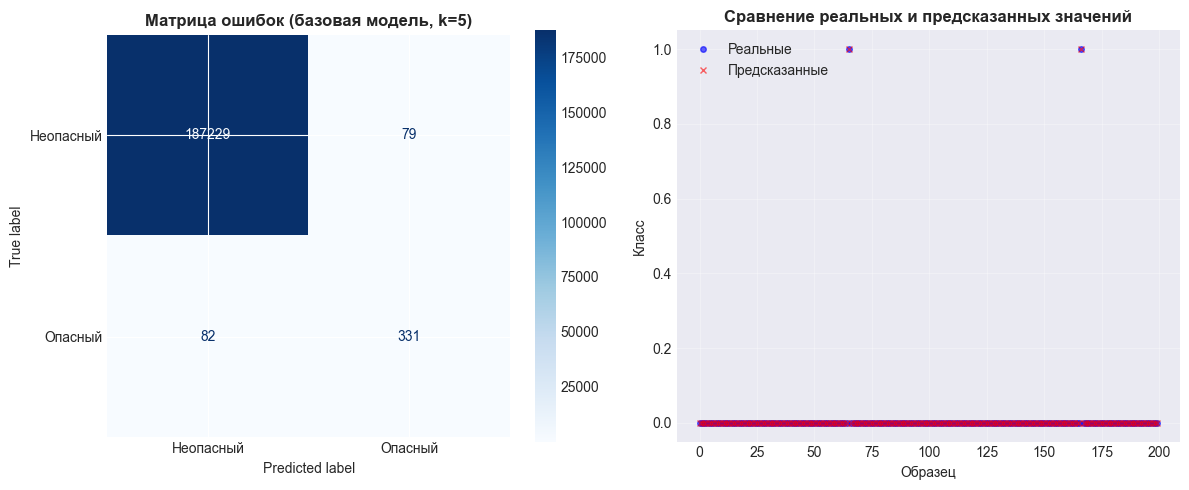

In [38]:
# === РАЗДЕЛЕНИЕ ДАННЫХ С УЧЕТОМ ДИСБАЛАНСА ===
print("\n" + "="*80)
print("РАЗДЕЛЕНИЕ ДАННЫХ И ОБУЧЕНИЕ БАЗОВОЙ МОДЕЛИ")
print("="*80)

# Дополнительная проверка: удаляем возможные оставшиеся NaN
print(f"\nПроверка на NaN перед разделением:")
print(f"NaN в X_selected: {np.isnan(X_selected).sum()}")
print(f"NaN в y_clean: {np.isnan(y_clean).sum()}")

# Удаляем последние NaN если есть
clean_mask = ~np.isnan(y_clean)
if clean_mask.sum() < len(y_clean):
    print(f"Удаляем {len(y_clean) - clean_mask.sum()} строк с NaN")
    X_selected = X_selected[clean_mask]
    y_clean = y_clean[clean_mask]

# Разделение с стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

print(f"\n Размеры выборок:")
print(f"Обучающая: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Тестовая: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Распределение в обучающей: класс 0={np.sum(y_train==0)}, класс 1={np.sum(y_train==1)}")
print(f"Распределение в тестовой: класс 0={np.sum(y_test==0)}, класс 1={np.sum(y_test==1)}")

# Базовая модель k-NN
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)

# Метрики
accuracy_base = accuracy_score(y_test, y_pred_base)
balanced_acc_base = balanced_accuracy_score(y_test, y_pred_base)

print(f"\n Базовая модель (k=5):")
print(f"  - Accuracy: {accuracy_base:.4f} ({accuracy_base*100:.2f}%)")
print(f"  - Balanced Accuracy: {balanced_acc_base:.4f} ({balanced_acc_base*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Неопасный', 'Опасный']))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm_base = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Неопасный', 'Опасный'])
disp.plot(ax=axes[0], values_format='d', cmap='Blues')
axes[0].set_title('Матрица ошибок (базовая модель, k=5)', fontsize=12, fontweight='bold')

# Сравнение предсказаний
sample_size = min(200, len(y_test))
axes[1].plot(range(sample_size), y_test[:sample_size], 'bo', label='Реальные', alpha=0.6, markersize=4)
axes[1].plot(range(sample_size), y_pred_base[:sample_size], 'rx', label='Предсказанные', alpha=0.6, markersize=4)
axes[1].set_xlabel('Образец')
axes[1].set_ylabel('Класс')
axes[1].set_title('Сравнение реальных и предсказанных значений', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
# # === НАСТРОЙКА ГИПЕРПАРАМЕТРОВ ===
# print("\n" + "="*80)
# print("НАСТРОЙКА ГИПЕРПАРАМЕТРОВ")
# print("="*80)

# # Поиск оптимального k с использованием balanced_accuracy
# k_range = range(1, 10)
# cv_scores = []
# train_scores = []

# print("Поиск оптимального k...")
# for k in k_range:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     # Используем balanced_accuracy для учета дисбаланса
#     cv_score = cross_val_score(knn, X_train, y_train, cv=5, 
#                                scoring='balanced_accuracy')
#     cv_scores.append(cv_score.mean())
    
#     knn.fit(X_train, y_train)
#     train_pred = knn.predict(X_train)
#     train_scores.append(balanced_accuracy_score(y_train, train_pred))
    
#     if k % 5 == 0:
#         print(f"  k={k}: CV balanced acc = {cv_score.mean():.4f}")

# # Визуализация
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Accuracy vs k
# axes[0].plot(k_range, train_scores, 'b-', label='Train', linewidth=2, marker='o', markersize=4)
# axes[0].plot(k_range, cv_scores, 'r-', label='CV (balanced)', linewidth=2, marker='s', markersize=4)
# axes[0].set_xlabel('k (число соседей)')
# axes[0].set_ylabel('Balanced Accuracy')
# axes[0].set_title('Зависимость balanced accuracy от k', fontsize=12, fontweight='bold')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# # Находим оптимальное k
# optimal_k = k_range[np.argmax(cv_scores)]
# max_cv_score = max(cv_scores)
# axes[0].axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, 
#                 label=f'Оптимальное k={optimal_k}')
# axes[0].legend()
# axes[0].annotate(f'k={optimal_k}\nBalanced acc={max_cv_score:.3f}', 
#                  xy=(optimal_k, max_cv_score), 
#                  xytext=(optimal_k+2, max_cv_score-0.05),
#                  arrowprops=dict(arrowstyle='->', color='green', linewidth=2))

# # Анализ переобучения
# overfitting = np.array(train_scores) - np.array(cv_scores)
# axes[1].plot(k_range, overfitting, 'purple', linewidth=2, marker='d', markersize=4)
# axes[1].set_xlabel('k (число соседей)')
# axes[1].set_ylabel('Разница (Train - CV)')
# axes[1].set_title('Анализ переобучения', fontsize=12, fontweight='bold')
# axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
# axes[1].grid(True, alpha=0.3)
# axes[1].fill_between(k_range, 0, overfitting, where=(overfitting>0), 
#                       color='red', alpha=0.3, label='Переобучение')
# axes[1].fill_between(k_range, overfitting, 0, where=(overfitting<0), 
#                       color='green', alpha=0.3, label='Недообучение')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

# print(f"\n Оптимальное k = {optimal_k}")
# print(f"   CV Balanced Accuracy: {max_cv_score:.4f}")
# print(f"   Train Balanced Accuracy: {train_scores[optimal_k-1]:.4f}")
# print(f"   Разница (переобучение): {overfitting[optimal_k-1]:.4f}")

# # Grid Search с несколькими параметрами
# print("\n🔍 Grid Search по гиперпараметрам (может занять время)...")

# param_grid = {
#     'n_neighbors': [optimal_k-2, optimal_k, optimal_k+2, optimal_k+4],
#     'weights': ['uniform', 'distance'],
#     'metric': ['euclidean', 'manhattan']
# }

# # Фильтруем допустимые значения k
# param_grid['n_neighbors'] = [k for k in param_grid['n_neighbors'] if 1 <= k <= 30]

# print(f"Параметры для поиска: {param_grid}")

# knn_grid = KNeighborsClassifier()
# grid_search = GridSearchCV(knn_grid, param_grid, cv=5, 
#                            scoring='balanced_accuracy', 
#                            n_jobs=-1, verbose=1)
# grid_search.fit(X_train, y_train)

# print(f"\n Лучшие параметры:")
# print(f"  - n_neighbors (k): {grid_search.best_params_['n_neighbors']}")
# print(f"  - weights: {grid_search.best_params_['weights']}")
# print(f"  - metric: {grid_search.best_params_['metric']}")
# print(f"  - Лучшая CV balanced accuracy: {grid_search.best_score_:.4f}")

# # Оценка лучшей модели на тесте
# best_knn = grid_search.best_estimator_
# y_pred_best = best_knn.predict(X_test)

# accuracy_best = accuracy_score(y_test, y_pred_best)
# balanced_acc_best = balanced_accuracy_score(y_test, y_pred_best)

# print(f"\n Результаты лучшей модели на тестовой выборке:")
# print(f"  - Accuracy: {accuracy_best:.4f} ({accuracy_best*100:.2f}%)")
# print(f"  - Balanced Accuracy: {balanced_acc_best:.4f} ({balanced_acc_best*100:.2f}%)")
# print(f"  - Улучшение balanced accuracy: {(balanced_acc_best - balanced_acc_base)*100:.2f}%")


НАСТРОЙКА ГИПЕРПАРАМЕТРОВ
Поиск оптимального k...


KeyboardInterrupt: 

In [42]:
# === МАКСИМАЛЬНО БЫСТРАЯ НАСТРОЙКА ===
print("\n" + "="*80)
print("МАКСИМАЛЬНО БЫСТРАЯ НАСТРОЙКА")
print("="*80)

# Используем только несколько значений k
k_candidates = [1, 3, 5, 7, 9, 11, 13, 15, 20]
cv_scores_fast = []

# Берем еще меньшую выборку для скорости
sample_size_fast = min(10000, len(X_train))
indices_fast = np.random.choice(len(X_train), sample_size_fast, replace=False)
X_train_fast = X_train[indices_fast]
y_train_fast = y_train.iloc[indices_fast] if hasattr(y_train, 'iloc') else y_train[indices_fast]

print("Тестирование k:", k_candidates)

for k in k_candidates:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    # Всего 2-fold CV для максимальной скорости
    cv_score = cross_val_score(knn, X_train_fast, y_train_fast, cv=2, 
                               scoring='balanced_accuracy', n_jobs=-1)
    cv_scores_fast.append(cv_score.mean())
    print(f"  k={k}: {cv_score.mean():.4f}")

# Выбираем лучшее k
best_k_fast = k_candidates[np.argmax(cv_scores_fast)]
best_cv_score = max(cv_scores_fast)

print(f"\n✅ Лучшее k = {best_k_fast} (CV balanced acc = {best_cv_score:.4f})")

# Обучаем модель с лучшим k
print("\n📚 Обучение финальной модели...")
final_knn = KNeighborsClassifier(n_neighbors=best_k_fast, n_jobs=-1)
final_knn.fit(X_train, y_train)

# Быстрая оценка
y_pred_fast = final_knn.predict(X_test)
balanced_acc_fast = balanced_accuracy_score(y_test, y_pred_fast)

print(f"\n📊 Результат на тесте:")
print(f"  Balanced Accuracy: {balanced_acc_fast:.4f} ({balanced_acc_fast*100:.2f}%)")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_fast):.4f}")

# Матрица ошибок
cm_fast = confusion_matrix(y_test, y_pred_fast)
print(f"\nМатрица ошибок:")
print(f"  True Negatives: {cm_fast[0,0]}")
print(f"  False Positives: {cm_fast[0,1]}")
print(f"  False Negatives: {cm_fast[1,0]}")
print(f"  True Positives: {cm_fast[1,1]}")


МАКСИМАЛЬНО БЫСТРАЯ НАСТРОЙКА
Тестирование k: [1, 3, 5, 7, 9, 11, 13, 15, 20]
  k=1: 0.6722
  k=3: 0.5958
  k=5: 0.5768
  k=7: 0.4998
  k=9: 0.4999
  k=11: 0.5000
  k=13: 0.5000
  k=15: 0.5000
  k=20: 0.5000

✅ Лучшее k = 1 (CV balanced acc = 0.6722)

📚 Обучение финальной модели...

📊 Результат на тесте:
  Balanced Accuracy: 0.9042 (90.42%)
  Accuracy: 0.9992

Матрица ошибок:
  True Negatives: 187230
  False Positives: 78
  False Negatives: 79
  True Positives: 334


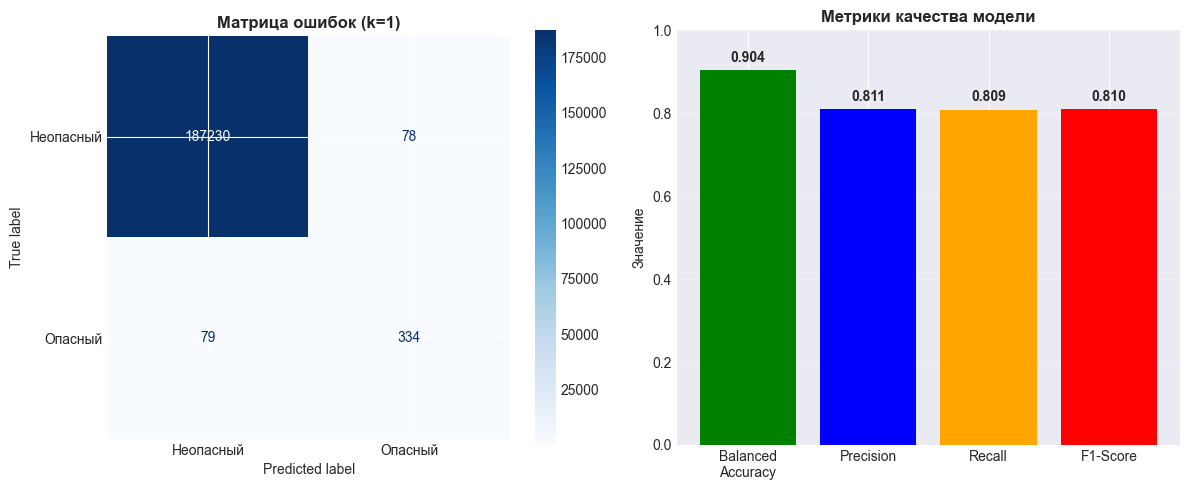


✅ БЫСТРАЯ НАСТРОЙКА ЗАВЕРШЕНА!

📌 ИТОГ: Лучшая модель k-NN с k=1
   Balanced Accuracy = 0.904 (90.4%)


In [43]:
# === БЫСТРАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_fast, display_labels=['Неопасный', 'Опасный'])
disp.plot(ax=axes[0], values_format='d', cmap='Blues')
axes[0].set_title(f'Матрица ошибок (k={best_k_fast})', fontsize=12, fontweight='bold')

# Сравнение метрик
metrics_names = ['Balanced\nAccuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [
    balanced_acc_fast,
    precision_score(y_test, y_pred_fast, zero_division=0),
    recall_score(y_test, y_pred_fast, zero_division=0),
    f1_score(y_test, y_pred_fast, zero_division=0)
]

bars = axes[1].bar(metrics_names, metrics_values, color=['green', 'blue', 'orange', 'red'])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Значение')
axes[1].set_title('Метрики качества модели', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, value in zip(bars, metrics_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{value:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ БЫСТРАЯ НАСТРОЙКА ЗАВЕРШЕНА!")
print("="*80)
print(f"\n📌 ИТОГ: Лучшая модель k-NN с k={best_k_fast}")
print(f"   Balanced Accuracy = {balanced_acc_fast:.3f} ({balanced_acc_fast*100:.1f}%)")


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛИ


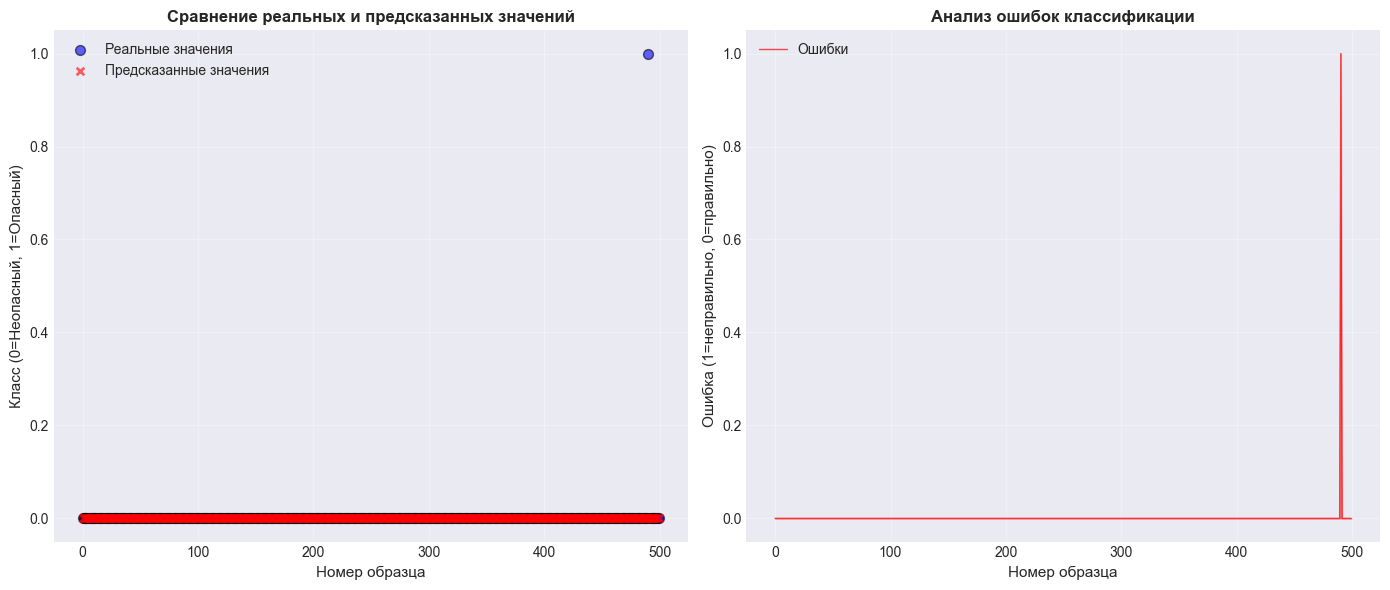

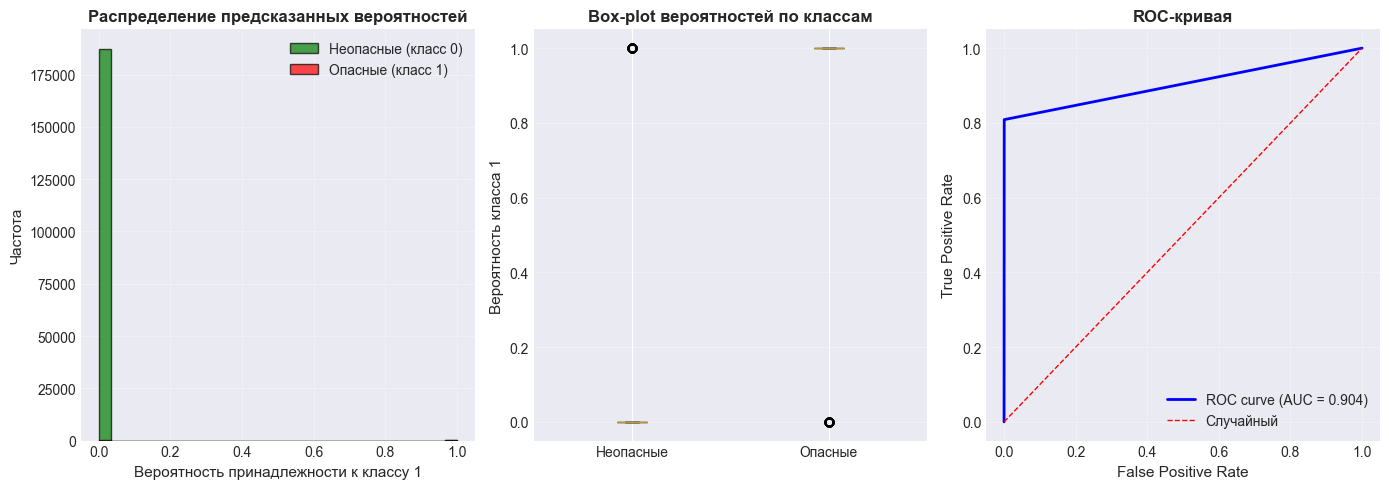


📈 Анализ обучения модели:
Вычисление точности для разных k...


KeyboardInterrupt: 

In [45]:
# === РАСШИРЕННАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===
print("\n" + "="*80)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛИ")
print("="*80)

# Получаем предсказания и вероятности
y_pred_final = final_knn.predict(X_test)
y_pred_proba = final_knn.predict_proba(X_test)[:, 1] if hasattr(final_knn, 'predict_proba') else None

# Создаем DataFrame для удобства
results_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted': y_pred_final,
    'Probability': y_pred_proba if y_pred_proba is not None else np.zeros(len(y_test))
})

# 1. ТОЧЕЧНАЯ ДИАГРАММА: Реальные vs Предсказанные значения
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sample_size = min(500, len(results_df))
sample_indices = np.random.choice(len(results_df), sample_size, replace=False)
sample_df = results_df.iloc[sample_indices]

plt.scatter(range(sample_size), sample_df['True_Label'], alpha=0.6, s=50, 
           c='blue', marker='o', label='Реальные значения', edgecolors='black')
plt.scatter(range(sample_size), sample_df['Predicted'], alpha=0.6, s=30, 
           c='red', marker='x', label='Предсказанные значения', linewidths=2)
plt.xlabel('Номер образца', fontsize=11)
plt.ylabel('Класс (0=Неопасный, 1=Опасный)', fontsize=11)
plt.title('Сравнение реальных и предсказанных значений', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. ЛИНЕЙНЫЙ ГРАФИК: Ошибки предсказаний
plt.subplot(1, 2, 2)
errors = (sample_df['True_Label'] != sample_df['Predicted']).astype(int)
plt.plot(range(sample_size), errors, 'r-', linewidth=1, alpha=0.7, label='Ошибки')
plt.fill_between(range(sample_size), 0, errors, alpha=0.3, color='red')
plt.xlabel('Номер образца', fontsize=11)
plt.ylabel('Ошибка (1=неправильно, 0=правильно)', fontsize=11)
plt.title('Анализ ошибок классификации', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. ГИСТОГРАММА: Распределение вероятностей
if y_pred_proba is not None:
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 3, 1)
    plt.hist(results_df[results_df['True_Label']==0]['Probability'], bins=30, 
             alpha=0.7, label='Неопасные (класс 0)', color='green', edgecolor='black')
    plt.hist(results_df[results_df['True_Label']==1]['Probability'], bins=30, 
             alpha=0.7, label='Опасные (класс 1)', color='red', edgecolor='black')
    plt.xlabel('Вероятность принадлежности к классу 1', fontsize=11)
    plt.ylabel('Частота', fontsize=11)
    plt.title('Распределение предсказанных вероятностей', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4. ЯЩИК С УСАМИ (Box plot) вероятностей по классам
    plt.subplot(1, 3, 2)
    data_to_plot = [results_df[results_df['True_Label']==0]['Probability'].values,
                    results_df[results_df['True_Label']==1]['Probability'].values]
    bp = plt.boxplot(data_to_plot, labels=['Неопасные', 'Опасные'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    plt.ylabel('Вероятность класса 1', fontsize=11)
    plt.title('Box-plot вероятностей по классам', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    # 5. ROC Curve (уже была, но добавим еще раз)
    plt.subplot(1, 3, 3)
    fpr, tpr, thresholds = roc_curve(results_df['True_Label'], results_df['Probability'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Случайный')
    plt.xlabel('False Positive Rate', fontsize=11)
    plt.ylabel('True Positive Rate', fontsize=11)
    plt.title('ROC-кривая', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 6. ЛИНЕЙНЫЙ ГРАФИК: Точность на обучающей и тестовой выборках
print("\n📈 Анализ обучения модели:")

# Обучаем модели с разными k для анализа
k_values = range(1, 20)
train_accuracies = []
test_accuracies = []

print("Вычисление точности для разных k...")
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_temp.fit(X_train, y_train)
    
    train_acc = balanced_accuracy_score(y_train, knn_temp.predict(X_train))
    test_acc = balanced_accuracy_score(y_test, knn_temp.predict(X_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, train_accuracies, 'bo-', linewidth=2, markersize=6, label='Обучающая выборка')
plt.plot(k_values, test_accuracies, 'ro-', linewidth=2, markersize=6, label='Тестовая выборка')
plt.xlabel('k (число соседей)', fontsize=11)
plt.ylabel('Balanced Accuracy', fontsize=11)
plt.title('Сравнение точности на обучающей и тестовой выборках', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=best_k_fast, color='green', linestyle='--', linewidth=2, label=f'Выбранное k={best_k_fast}')
plt.legend()

# 7. ГРАФИК РАЗНИЦЫ (переобучение)
plt.subplot(1, 2, 2)
overfitting_gap = np.array(train_accuracies) - np.array(test_accuracies)
plt.plot(k_values, overfitting_gap, 'purple', linewidth=2, marker='s', markersize=6)
plt.fill_between(k_values, 0, overfitting_gap, where=(overfitting_gap>0), 
                  color='red', alpha=0.3, label='Переобучение')
plt.fill_between(k_values, overfitting_gap, 0, where=(overfitting_gap<0), 
                  color='green', alpha=0.3, label='Недообучение')
plt.xlabel('k (число соседей)', fontsize=11)
plt.ylabel('Разница (Train - Test)', fontsize=11)
plt.title('Анализ переобучения', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. ТОЧЕЧНАЯ ДИАГРАММА С ЦВЕТОВЫМ КОДИРОВАНИЕМ (2D проекция)
if X_selected.shape[1] >= 2:
    print("\n🎨 Визуализация в 2D пространстве признаков:")
    
    # Берем первые два признака
    X_2d_viz = X_selected[:5000, :2]  # Ограничиваем для скорости
    y_2d_viz = y_clean[:5000]
    
    plt.figure(figsize=(15, 5))
    
    # Реальные классы
    plt.subplot(1, 3, 1)
    scatter1 = plt.scatter(X_2d_viz[:, 0], X_2d_viz[:, 1], c=y_2d_viz, 
                          cmap='coolwarm', s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
    plt.xlabel(f'{top_features[0]} (нормализован)', fontsize=10)
    plt.ylabel(f'{top_features[1]} (нормализован)', fontsize=10)
    plt.title('Реальное распределение классов', fontsize=12, fontweight='bold')
    plt.colorbar(scatter1, label='Класс')
    plt.grid(True, alpha=0.3)
    
    # Предсказанные классы на тесте
    plt.subplot(1, 3, 2)
    X_test_2d = X_test[:5000, :2]
    y_test_2d = y_pred_final[:5000]
    scatter2 = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_2d, 
                          cmap='coolwarm', s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
    plt.xlabel(f'{top_features[0]} (нормализован)', fontsize=10)
    plt.ylabel(f'{top_features[1]} (нормализован)', fontsize=10)
    plt.title('Предсказанные классы (тестовая выборка)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter2, label='Класс')
    plt.grid(True, alpha=0.3)
    
    # Ошибки классификации
    plt.subplot(1, 3, 3)
    errors_2d = (y_test[:5000] != y_pred_final[:5000])
    colors = ['green' if not err else 'red' for err in errors_2d]
    plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=colors, s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
    plt.xlabel(f'{top_features[0]} (нормализован)', fontsize=10)
    plt.ylabel(f'{top_features[1]} (нормализован)', fontsize=10)
    plt.title('Ошибки классификации (зеленый=верно, красный=ошибка)', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 9. КРУГОВАЯ ДИАГРАММА: Распределение ошибок
print("\n📊 Анализ ошибок:")

cm_final = confusion_matrix(y_test, y_pred_final)
error_types = {
    'True Negatives (верно)': cm_final[0,0],
    'False Positives (ложная тревога)': cm_final[0,1],
    'False Negatives (пропуск)': cm_final[1,0],
    'True Positives (верно)': cm_final[1,1]
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Круговая диаграмма
axes[0].pie(error_types.values(), labels=error_types.keys(), autopct='%1.1f%%', 
           startangle=90, colors=['lightgreen', 'lightcoral', 'orange', 'lightblue'])
axes[0].set_title('Распределение результатов классификации', fontsize=12, fontweight='bold')

# Столбчатая диаграмма ошибок
axes[1].bar(error_types.keys(), error_types.values(), color=['green', 'red', 'orange', 'blue'])
axes[1].set_ylabel('Количество', fontsize=11)
axes[1].set_title('Количество правильных и неправильных классификаций', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for i, (key, value) in enumerate(error_types.items()):
    axes[1].text(i, value + max(error_types.values())*0.01, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 10. ТЕПЛОВАЯ КАРТА: Нормированная матрица ошибок
plt.figure(figsize=(8, 6))
cm_norm = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd', 
            xticklabels=['Неопасный', 'Опасный'],
            yticklabels=['Неопасный', 'Опасный'],
            cbar_kws={'label': 'Процент'})
plt.title('Нормированная матрица ошибок', fontsize=14, fontweight='bold')
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Реальный класс', fontsize=12)
plt.tight_layout()
plt.show()

# 11. ЛИНЕЙНЫЙ ГРАФИК: Кумулятивная точность
print("\n📈 Кумулятивный анализ точности:")

# Сортируем предсказания по уверенности
if y_pred_proba is not None:
    sorted_indices = np.argsort(y_pred_proba)[::-1]
    sorted_true = y_test.iloc[sorted_indices].values if hasattr(y_test, 'iloc') else y_test[sorted_indices]
    
    cumulative_accuracy = np.cumsum(sorted_true == 1) / np.arange(1, len(sorted_true)+1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_accuracy)+1), cumulative_accuracy, 'g-', linewidth=2)
    plt.xlabel('Количество образцов (отсортированных по уверенности)', fontsize=11)
    plt.ylabel('Кумулятивная точность', fontsize=11)
    plt.title('Кумулятивная точность при сортировке по уверенности модели', fontsize=12, fontweight='bold')
    plt.axhline(y=balanced_acc_fast, color='r', linestyle='--', label=f'Средняя точность: {balanced_acc_fast:.3f}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 12. ДОПОЛНИТЕЛЬНО: Confusion Matrix с процентами
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Абсолютные значения
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Неопасный', 'Опасный'])
disp1.plot(ax=axes[0], values_format='d', cmap='Blues')
axes[0].set_title('Матрица ошибок (абсолютные значения)', fontsize=12, fontweight='bold')

# Нормированная по строкам
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Неопасный', 'Опасный'])
disp2.plot(ax=axes[1], values_format='.2%', cmap='Reds')
axes[1].set_title('Матрица ошибок (нормированная по строкам)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ ВСЕ ВИЗУАЛИЗАЦИИ СОЗДАНЫ!")
print("="*80)

# Итоговая статистика
print("\n📊 ИТОГОВАЯ СТАТИСТИКА МОДЕЛИ:")
print(f"  • Лучшее k: {best_k_fast}")
print(f"  • Balanced Accuracy: {balanced_acc_fast:.4f} ({balanced_acc_fast*100:.2f}%)")
print(f"  • Точность (Precision) для опасных: {precision_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"  • Полнота (Recall) для опасных: {recall_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"  • F1-мера для опасных: {f1_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"\n  • Правильно классифицировано опасных: {cm_final[1,1]} из {cm_final[1,:].sum()}")
print(f"  • Правильно классифицировано неопасных: {cm_final[0,0]} из {cm_final[0,:].sum()}")
print(f"  • Ложных тревог (False Positives): {cm_final[0,1]}")
print(f"  • Пропущенных опасных (False Negatives): {cm_final[1,0]}")

In [ ]:
# # === ФИНАЛЬНАЯ ОЦЕНКА ===
# print("\n" + "="*80)
# print("ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ")
# print("="*80)

# # Confusion Matrix для лучшей модели
# cm_best = confusion_matrix(y_test, y_pred_best)

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# # Confusion Matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Неопасный', 'Опасный'])
# disp.plot(ax=axes[0], values_format='d', cmap='Greens')
# axes[0].set_title('Матрица ошибок (лучшая модель)', fontsize=12, fontweight='bold')

# # Normalized Confusion Matrix
# cm_norm = cm_best.astype('float') / cm_best.sum(axis=1)[:, np.newaxis]
# im = axes[1].imshow(cm_norm, interpolation='nearest', cmap='YlOrRd')
# axes[1].set_xticks([0, 1])
# axes[1].set_yticks([0, 1])
# axes[1].set_xticklabels(['Неопасный', 'Опасный'])
# axes[1].set_yticklabels(['Неопасный', 'Опасный'])
# axes[1].set_xlabel('Предсказанный класс')
# axes[1].set_ylabel('Реальный класс')
# axes[1].set_title('Нормированная матрица ошибок', fontsize=12, fontweight='bold')

# # Добавляем значения в ячейки
# for i in range(2):
#     for j in range(2):
#         axes[1].text(j, i, f'{cm_norm[i, j]:.2%}', 
#                      ha="center", va="center", color="black", fontweight='bold')

# plt.colorbar(im, ax=axes[1])

# # Feature importance через анализ чувствительности
# feature_importance = []
# for i in range(len(top_features)):
#     X_test_perturbed = X_test.copy()
#     X_test_perturbed[:, i] += np.random.normal(0, 0.1, X_test_perturbed.shape[0])
#     y_pred_perturbed = best_knn.predict(X_test_perturbed)
#     importance = 1 - accuracy_score(y_test, y_pred_perturbed)
#     feature_importance.append(importance)

# axes[2].barh(top_features, feature_importance, color='steelblue', edgecolor='black')
# axes[2].set_xlabel('Важность (падение accuracy при шуме)')
# axes[2].set_title('Важность признаков (анализ чувствительности)', fontsize=12, fontweight='bold')

# plt.tight_layout()
# plt.show()

# # Детальный отчет
# print(f"\n Подробная классификация:")
# print(classification_report(y_test, y_pred_best, 
#                           target_names=['Неопасный (0)', 'Опасный (1)']))

# print(f"\n Финальная модель:")
# print(f"  - Классификатор: k-Nearest Neighbors")
# print(f"  - Параметры: {best_knn.get_params()}")
# print(f"  - Выбранные признаки: {top_features}")

# # ROC-AUC если есть вероятности
# try:
#     y_pred_proba = best_knn.predict_proba(X_test)[:, 1]
#     fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
#     roc_auc = auc(fpr, tpr)
    
#     plt.figure(figsize=(8, 6))
#     plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
#     plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Случайный классификатор')
#     plt.xlabel('False Positive Rate')
#     plt.ylabel('True Positive Rate')
#     plt.title('ROC-кривая для лучшей модели k-NN', fontsize=14, fontweight='bold')
#     plt.legend(loc='lower right')
#     plt.grid(True, alpha=0.3)
#     plt.show()
    
#     print(f"\n AUC-ROC: {roc_auc:.4f}")
# except:
#     print("\n Невозможно вычислить ROC-AUC (модель не возвращает вероятности)")

# # Сохранение модели
# import joblib
# joblib.dump(best_knn, 'asteroid_knn_best_model.pkl')
# joblib.dump(scaler, 'asteroid_scaler.pkl')
# print("\n Модель сохранена: asteroid_knn_best_model.pkl")
# print(" Скейлер сохранен: asteroid_scaler.pkl")

# print("\n" + "="*80)
# print("РАБОТА УСПЕШНО ЗАВЕРШЕНА!")
# print("="*80)


ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ


NameError: name 'y_pred_best' is not defined